# Income Prediction using Adult Census Income Dataset
## AI/ML Internship Project

##Name: Deep Talreja
##Registration Number: 23BCE11003
##Application Number: IN26010914

### Abstract
This project predicts whether a person's annual income exceeds $50K using machine learning classification algorithms.




In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/adult-census-income")

Using Colab cache for faster access to the 'adult-census-income' dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import *

#Load Dataset


In [ ]:
import os

df = pd.read_csv(os.path.join(path, 'adult.csv'))
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K



# Task 1: Dataset Understanding

The Adult Census Income Dataset contains demographic and employment-related information about individuals.

## Target Variable

- <=50K
- >50K

## Features

- Age
- Workclass
- Education
- Occupation
- Marital Status
- Relationship
- Race
- Sex
- Capital Gain
- Capital Loss
- Hours per Week
- Native Country

This dataset is used for a supervised binary classification problem where the objective is to predict whether a person's annual income exceeds $50,000.

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score
)

In [ ]:
import os

df = pd.read_csv(os.path.join(path, 'adult.csv'))

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


# Task 2 : Data Cleaning

Data cleaning is performed to improve the quality of the dataset.

The following operations are carried out:

- Identification of missing values.
- Replacement of '?' with NaN values.
- Removal of missing records.
- Removal of duplicate records.

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 1 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education.num   30139 non-null  int64 
 5   marital.status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital.gain    30139 non-null  int64 
 11  capital.loss    30139 non-null  int64 
 12  hours.per.week  30139 non-null  int64 
 13  native.country  30139 non-null  object
 14  income          30139 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#Task 3 : Feature Engineering

Feature engineering involves converting categorical variables into numerical form and scaling the features for better model performance.

The following steps are performed:

- Label Encoding
- Feature Selection
- Train-Test Split
- Feature Scaling

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

X = df.drop('income', axis=1)
y = df['income']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Task 4: Model Building

The following machine learning classification algorithms are implemented:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)


In [ ]:
lr = LogisticRegression()

dt = DecisionTreeClassifier()

rf = RandomForestClassifier()

knn = KNeighborsClassifier()

svm = SVC(probability=True)

In [ ]:
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'SVM': svm
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    ])

# Task 5: Performance Evaluation

The performance of all machine learning models is evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics help in comparing different models and selecting the most suitable model for income prediction.

In [ ]:
results = pd.DataFrame(
results,
columns=[
'Algorithm',
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC-AUC'
]
)

results

,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.823822,0.703586,0.460635,0.556761,0.846015
1,Decision Tree,0.807067,0.594684,0.618094,0.606163,0.742453
2,Random Forest,0.856669,0.729560,0.640884,0.682353,0.902532
3,KNN,0.825315,0.648832,0.594613,0.620541,0.843154
4,SVM,0.846218,0.742326,0.551105,0.632580,0.887379


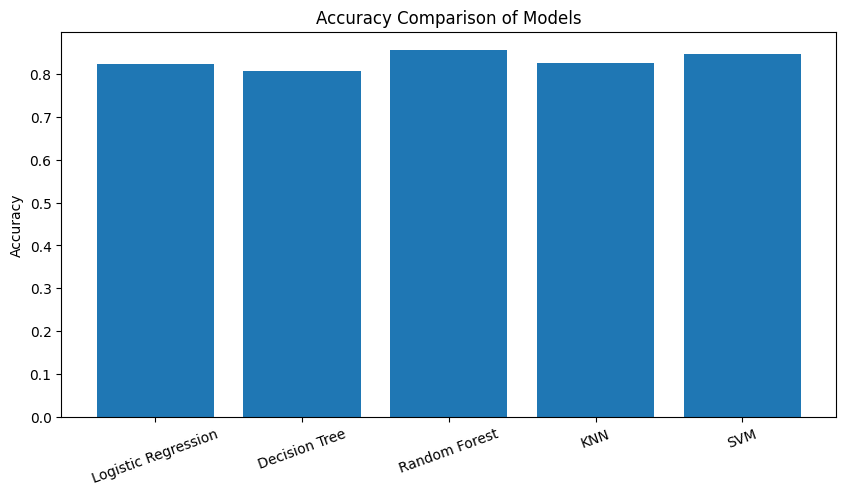

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(results['Algorithm'],
         results['Accuracy'])

plt.xticks(rotation=20)

plt.ylabel('Accuracy')

plt.title('Accuracy Comparison of Models')

plt.show()

# Conclusion

In this project, various machine learning classification algorithms were implemented for predicting whether a person's annual income exceeds $50,000.

The dataset was cleaned and preprocessed using missing value handling, duplicate removal, label encoding, and feature scaling techniques.

Five machine learning algorithms namely Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM) were trained and evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC metrics.

Based on the obtained results, the best-performing model can be identified for income prediction. Thus, machine learning techniques can effectively be used for solving binary classification problems.
